Loading and preprocessing data...

Training Random Forest Model...

Model Accuracy: 78.7%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


Generating Visualizations...
Saved: 'feature_importance.png'


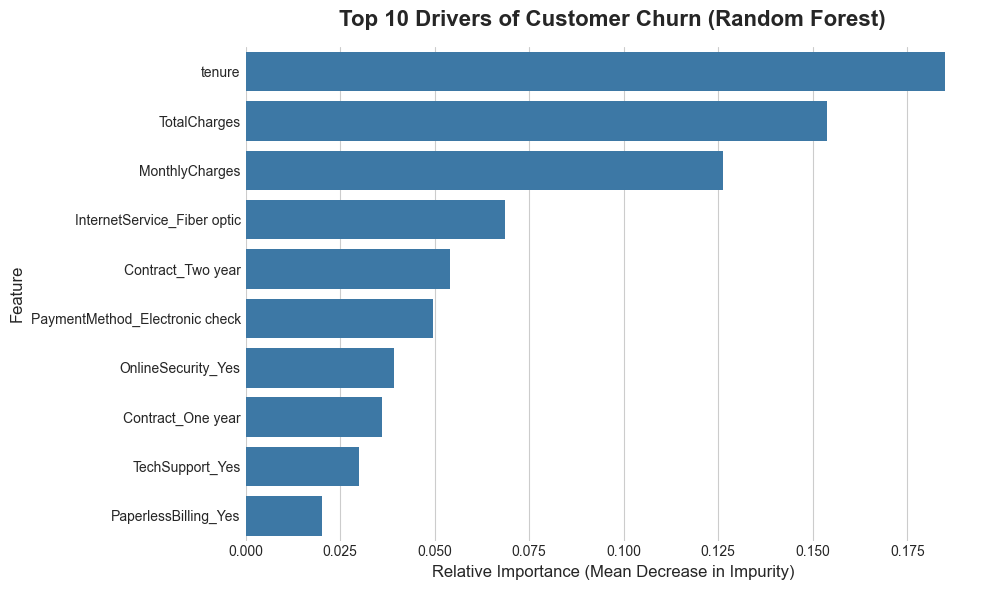

Saved: 'business_context.png'


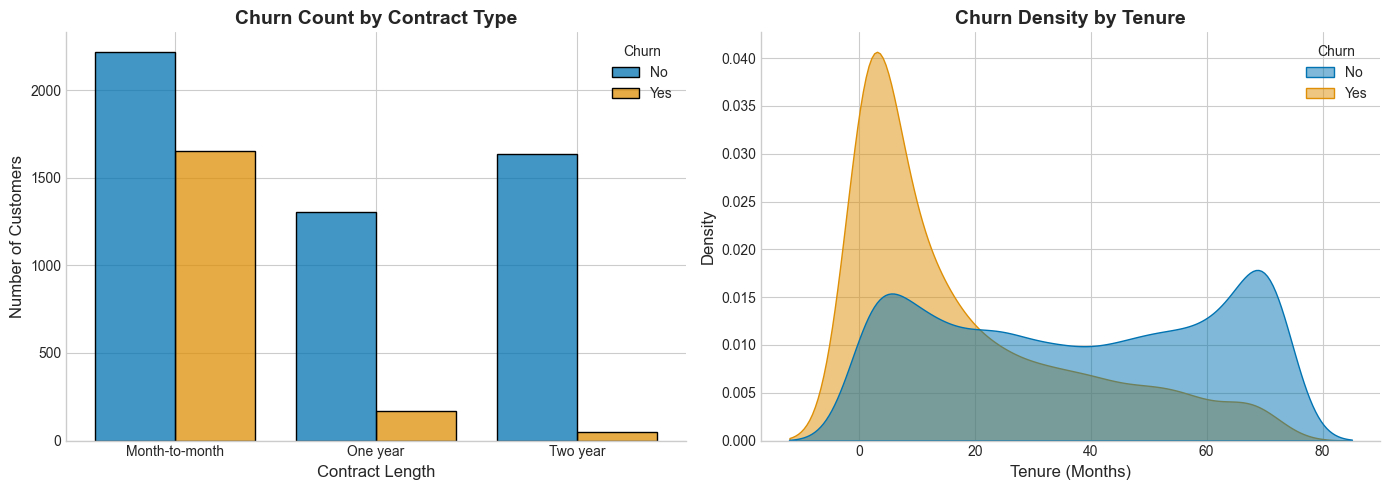

In [1]:
# ==========================================
# GitHub Repository: https://github.com/Jahirul039/Machine-Learning1
# ==========================================

# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set plot style for clean, readable charts and colorblind accessibility
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind") 

# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
print("Loading and preprocessing data...")
# Load the dataset (Make sure 'telco_churn.csv' is in the same folder as your code)
df = pd.read_csv('telco_churn.csv')

# Keep a copy of the original data for our second visualization (for clean text labels)
clean_df = df.copy()

# 'TotalCharges' is imported as an object because of blank spaces. Convert to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the missing rows (only 11 rows, so it's safe to drop)
df.dropna(inplace=True)
clean_df = clean_df.loc[df.index] # Keep clean_df aligned with dropped rows

# Drop 'customerID' as it holds no predictive value
df.drop('customerID', axis=1, inplace=True)

# Convert the target variable 'Churn' to binary (1 for Yes, 0 for No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert all other text/categorical columns into numerical formats using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
print("\nTraining Random Forest Model...")
# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Random Forest
# (max_depth=10 prevents the model from overfitting and makes it easier to explain)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Quick Evaluation
y_pred = rf_model.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 4. VISUALIZATION 1: FEATURE IMPORTANCE
# ==========================================
print("\nGenerating Visualizations...")

# Extract Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame to sort and plot
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Get the top 10 most important features
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot Feature Importances
plt.figure(figsize=(10, 6))
# Using a single, high-contrast color for accessibility
sns.barplot(x='Importance', y='Feature', data=top_10_features, color='#2c7bb6')

plt.title('Top 10 Drivers of Customer Churn (Random Forest)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Clean up the chart boundaries (despine)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# ---> ADDED: Save the first figure automatically
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("Saved: 'feature_importance.png'")

plt.show()

# ==========================================
# 5. VISUALIZATION 2: BUSINESS CONTEXT
# ==========================================
# Visualizing the real-world impact of the most important features (Contract & Tenure)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Churn by Contract Type (Using clean_df for readable labels)
sns.histplot(data=clean_df, x='Contract', hue='Churn', multiple='dodge', shrink=.8, palette='colorblind', ax=ax1)
ax1.set_title('Churn Count by Contract Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Contract Length', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)

# Plot B: Churn by Tenure (Months with company)
sns.kdeplot(data=clean_df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='colorblind', alpha=0.5, ax=ax2)
ax2.set_title('Churn Density by Tenure', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tenure (Months)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)

sns.despine()
plt.tight_layout()

# ---> ADDED: Save the second figure automatically
plt.savefig('business_context.png', dpi=300, bbox_inches='tight')
print("Saved: 'business_context.png'")

plt.show()